In [1]:
import os
import zipfile
from pathlib import Path
import pandas as pd
import re
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from PIL import Image
from sklearn.model_selection import train_test_split
tqdm.pandas()
ROOT_DIR = Path("/kaggle/input/datasets/glitchr/eurodata")
OUT_DIR =  Path("/kaggle/working/output")
RGB_DIR = ROOT_DIR / "EuroSAT_RGB"
MS_DIR = ROOT_DIR / "EuroSAT_MS"
SAR_DIR = ROOT_DIR / "EuroSAT-SAR"
OUT_DIR.mkdir(parents=True, exist_ok=True)
VALID_EXTENSIONS = {
    ".jpg", ".jpeg", ".png",
    ".tif", ".tiff"
}

IMAGE_EXTENSIONS = {
    ".tif", ".tiff",
    ".jpg", ".jpeg",
    ".png"
}
CLASS_NAMES = ['AnnualCrop', 'Forest', 'HerbaceousVegetation',
               'Highway','Industrial', 'Pasture', 'PermanentCrop', 
               'Residential', 'River','SeaLake']
CLASS_IDX = {i:idx for idx,i in enumerate(CLASS_NAMES)}
os.makedirs(ROOT_DIR, exist_ok=True)

datasets = [
    {
        "name": "EuroSAT-SAR",
        "url": "https://huggingface.co/datasets/wangyi111/EuroSAT-SAR/resolve/main/EuroSAT-SAR.zip?download=true",
    },
    {
        "name": "EuroSAT_RGB",
        "url": "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1",
    },
    {
        "name": "EuroSAT_MS",
        "url": "https://zenodo.org/records/7711810/files/EuroSAT_MS.zip?download=1",
    }
]

for ds in datasets:
    zip_path = os.path.join(ROOT_DIR, f"{ds['name']}.zip")
    extract_dir = os.path.join(ROOT_DIR, ds["name"])

    # Download only if zip doesn't exist
    if not os.path.exists(zip_path):
        print(f"Downloading {ds['name']}...")
        !wget -c "{ds['url']}" -O "{zip_path}"
    else:
        print(f"{zip_path} already exists. Skipping download.")

    # Extract only if folder doesn't exist
    if not os.path.exists(extract_dir):
        print(f"Extracting {ds['name']}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(ROOT_DIR)
    else:
        print(f"{extract_dir} already exists. Skipping extraction.")

print("Done!")

/kaggle/input/datasets/glitchr/eurodata/EuroSAT-SAR.zip: Read-only file system
/kaggle/input/datasets/glitchr/eurodata/EuroSAT-SAR already exists. Skipping extraction.
/kaggle/input/datasets/glitchr/eurodata/EuroSAT_RGB.zip: Read-only file system
/kaggle/input/datasets/glitchr/eurodata/EuroSAT_RGB already exists. Skipping extraction.
/kaggle/input/datasets/glitchr/eurodata/EuroSAT_MS.zip: Read-only file system
/kaggle/input/datasets/glitchr/eurodata/EuroSAT_MS already exists. Skipping extraction.
Done!


In [2]:
def extract_file_id(file_path):
    """
    Extract numeric ID from filenames such as:
    AnnualCrop_1.jpg -> 1
    Forest_245.tif   -> 245
    """
    numbers = re.findall(r"\d+", file_path.stem)

    if not numbers:
        return None

    return int(numbers[-1]),file_path.parent.stem


def collect_modality_files(root_dir, modality_name):
    records = []

    for label_folder in sorted(root_dir.iterdir()):

        if not label_folder.is_dir():
            continue

        image_files = sorted([
            file
            for file in label_folder.rglob("*")
            if (
                file.is_file()
                and file.suffix.lower() in VALID_EXTENSIONS
            )
        ])

        for image_path in image_files:
            image_path

            file_id,label = extract_file_id(image_path)

            records.append({
                "file_id": file_id,
                "label": label,
                f"{modality_name}_id": image_path.stem,
                f"{modality_name}_path": str(image_path)
            })

    return pd.DataFrame(records)

In [4]:
rgb_df = collect_modality_files(
    RGB_DIR,
    "EuroSAT_RGB"
)

# ms_df = collect_modality_files(
#     MS_DIR,
#     "EuroSAT_MS"
# )

# sar_df = collect_modality_files(
#     SAR_DIR,
#     "EuroSAT_SAR"
# )
# df = rgb_df.merge(ms_df, on=["file_id", "label"], how="outer").merge(  sar_df,on=["file_id", "label"],how="outer")
df = rgb_df.copy()
print("RGB files:", len(rgb_df))
# print("MS files :", len(ms_df))
# print("SAR files:", len(sar_df))

RGB files: 27000


In [5]:
final_df = df.copy()
final_df['target'] = final_df.label.map(lambda x: int(CLASS_IDX[x]))
final_df = final_df.dropna(subset=["file_id", "label"])
final_df["file_id"] = final_df["file_id"].astype(int)
final_df = final_df.drop_duplicates(
    subset=["file_id", "label"]
).reset_index(drop=True)
print("Final dataframe shape:", final_df.shape)
display(final_df.head())

Final dataframe shape: (27000, 5)


,file_id,label,EuroSAT_RGB_id,EuroSAT_RGB_path,target
0,1,AnnualCrop,AnnualCrop_1,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0
1,10,AnnualCrop,AnnualCrop_10,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0
2,100,AnnualCrop,AnnualCrop_100,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0
3,1000,AnnualCrop,AnnualCrop_1000,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0
4,1001,AnnualCrop,AnnualCrop_1001,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0


In [7]:
train_df, temp_df = train_test_split(
    final_df,
    test_size=0.30,
    random_state=42,
    stratify=final_df["label"],
    shuffle=True
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"],
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Data Pipeline

In [8]:
import tensorflow as tf
IMAGE_SIZE = 64
IMAGE_CHANNELS = 3
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

RANDOM_SEED = 42
NUM_CLASSES = df.label.nunique()
NUM_CLASSES

2026-06-23 12:03:06.723093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782216186.905983      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782216186.959618      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782216187.407753      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782216187.407797      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782216187.407800      58 computation_placer.cc:177] computation placer alr

10

In [9]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    image = tf.cast(image, tf.float32)
    # image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label,tf.int32)
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label
    
def preprocess_train(image_path, label, augment):

    image, label = load_image(
        image_path,
        label
    )
    if tf.random.uniform(())<0.5:
        image = tf.image.random_flip_left_right(image)
    if tf.random.uniform(())>0.5:
        image = tf.image.random_flip_up_down(image)
    if tf.random.uniform(())<0.5:
        image = tf.image.random_brightness(
            image,
            max_delta=0.1
        )
    return image, label

def get_data(df,
                    batch_size=64,
                    augment=False,
                    shuffle=False,
                    repeat=False,
                    drop_remainder=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (df["EuroSAT_RGB_path"].values,
         df["target"].values.astype(np.int32))
    )

    ds = ds.map(lambda x,y:preprocess_train(x,y,augment), num_parallel_calls=tf.data.AUTOTUNE)

    if repeat:
        ds = ds.repeat()

    if shuffle:
        ds = ds.shuffle(len(df))

    ds = ds.batch(
        batch_size,
        drop_remainder=drop_remainder
    )

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [10]:
ds = get_data(train_df,augment = True,)

I0000 00:00:1782216199.974334      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782216199.980371      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


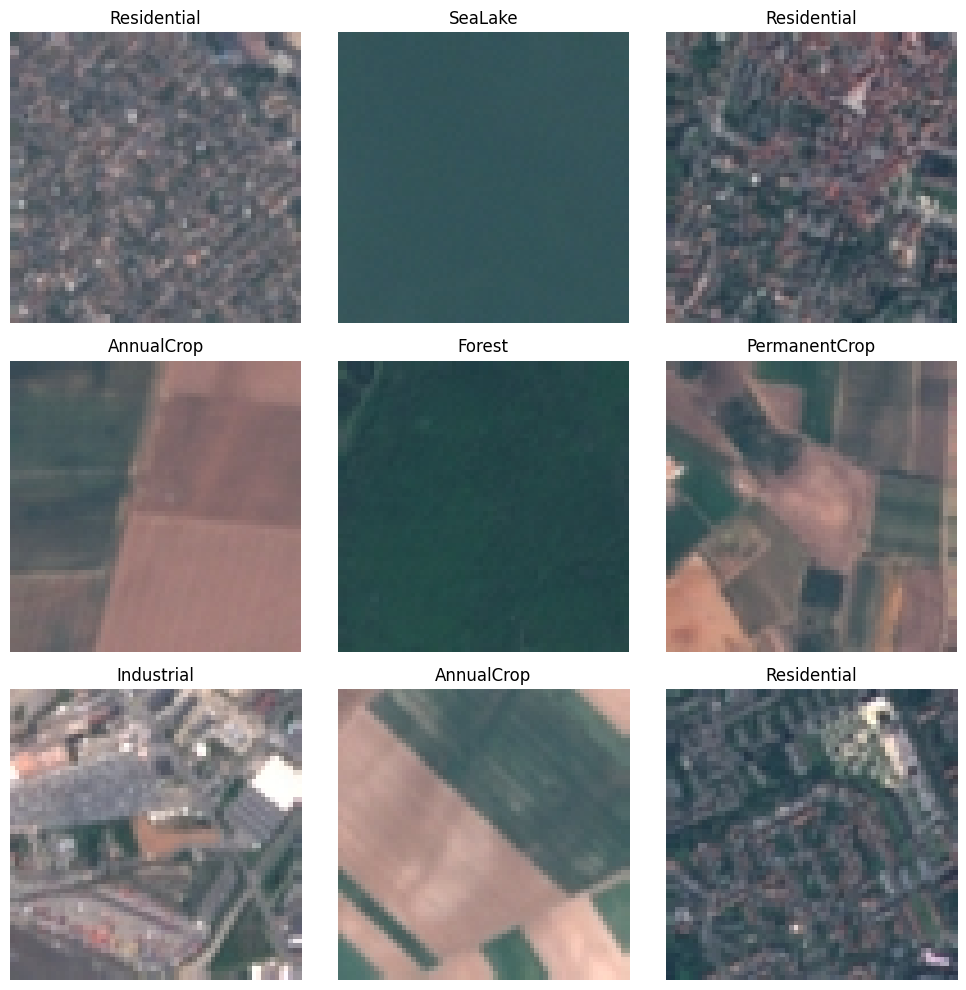

In [11]:
plt.figure(figsize=(10, 10))

for images, labels in ds.take(1):

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        image = tf.clip_by_value(
            images[i],
            0,
            255
        )

        plt.imshow(
            tf.cast(image, tf.int32)
        )

        label_id = int(labels[i].numpy().argmax())

        plt.title(
            CLASS_NAMES[label_id]
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
train_ds = get_data(train_df, augment=True, shuffle=True)
val_ds = get_data(val_df, augment=False, shuffle=False)
test_ds = get_data(test_df, augment=False, shuffle=False)

In [13]:
import time
import gc
INPUT_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, 3)
EPOCHS = 20
LEARNING_RATE = 1e-3

MODEL_DIR = Path("/kaggle/working/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)
loss="categorical_crossentropy"

Number of classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [14]:
MODEL_REGISTRY = {
    "MobileNetV2": tf.keras.applications.MobileNetV2,
    "MobileNetV3Large": tf.keras.applications.MobileNetV3Large,
    "ResNet50": tf.keras.applications.ResNet50,
    "ResNet101": tf.keras.applications.ResNet101,
    "DenseNet121": tf.keras.applications.DenseNet121,
    "EfficientNetB0": tf.keras.applications.EfficientNetB0,
    "EfficientNetB3": tf.keras.applications.EfficientNetB3,
    "EfficientNetV2B0": tf.keras.applications.EfficientNetV2B0,
    "Xception": tf.keras.applications.Xception,
    "InceptionV3": tf.keras.applications.InceptionV3,
    "ConvNeXtTiny": tf.keras.applications.ConvNeXtTiny,
    "VGG16": tf.keras.applications.VGG16
}

In [15]:
PREPROCESS_REGISTRY = {
    "MobileNetV2":
        tf.keras.applications.mobilenet_v2.preprocess_input,

    "ResNet50":
        tf.keras.applications.resnet.preprocess_input,

    "ResNet101":
        tf.keras.applications.resnet.preprocess_input,

    "DenseNet121":
        tf.keras.applications.densenet.preprocess_input,

    "Xception":
        tf.keras.applications.xception.preprocess_input,

    "InceptionV3":
        tf.keras.applications.inception_v3.preprocess_input,

    "VGG16":
        tf.keras.applications.vgg16.preprocess_input
}

In [16]:
def get_model(
    model_name,
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    dropout_rate=0.30,
    base_trainable=False
):
    if model_name not in MODEL_REGISTRY:
        raise ValueError(
            f"Unknown model: {model_name}\n"
            f"Available models: {list(MODEL_REGISTRY.keys())}"
        )

    model_class = MODEL_REGISTRY[model_name]

    inputs = tf.keras.layers.Input(
        shape=input_shape,
        name="optical_image"
    )

    x = inputs

    # Apply preprocessing only for models that need it
    if model_name in PREPROCESS_REGISTRY:
        preprocess_function = PREPROCESS_REGISTRY[model_name]

        x = tf.keras.layers.Lambda(
            preprocess_function,
            name=f"{model_name}_preprocessing"
        )(x)

    base_model = model_class(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape,
        pooling="avg"
    )

    base_model.trainable = base_trainable

    # Keep BatchNormalization layers in inference mode
    x = base_model(
        x,
        training=False
    )

    x = tf.keras.layers.BatchNormalization(
        name="feature_batch_norm"
    )(x)

    x = tf.keras.layers.Dropout(
        dropout_rate,
        name="feature_dropout"
    )(x)

    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        name="feature_dense"
    )(x)

    x = tf.keras.layers.Dropout(
        dropout_rate,
        name="classifier_dropout"
    )(x)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        name="classification_output"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"{model_name}_EuroSAT"
    )

    return model, base_model

In [19]:
def train_single_model(
    model_name,
    train_dataset,
    validation_dataset,
    test_dataset,
    epochs=15,
    learning_rate=1e-3
):
    print("\n" + "=" * 70)
    print("Training model:", model_name)
    print("=" * 70)

    tf.keras.backend.clear_session()
    gc.collect()

    model, base_model = get_model(
        model_name=model_name,
        input_shape=INPUT_SHAPE,
        num_classes=NUM_CLASSES,
        dropout_rate=0.30,
        base_trainable=False
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),

        loss=tf.keras.losses.CategoricalCrossentropy(),

        metrics=[
            tf.keras.metrics.CategoricalAccuracy(
                name="accuracy"
            ),

            tf.keras.metrics.TopKCategoricalAccuracy(
                k=5,
                name="top_5_accuracy"
            )
        ]
    )
    model.summary()
    model_path = (
        MODEL_DIR / f"{model_name}_best.keras"
    )

    model_callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

    start_time = time.time()

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=epochs,
        callbacks=model_callbacks,
        verbose=1
    )

    training_time = time.time() - start_time

    test_metrics = model.evaluate(
        test_dataset,
        return_dict=True,
        verbose=1
    )

    result = {
        "model": model_name,
        "parameters": model.count_params(),
        "best_train_accuracy": max(
            history.history["accuracy"]
        ),
        "best_validation_accuracy": max(
            history.history["val_accuracy"]
        ),
        "test_accuracy": test_metrics["accuracy"],
        "test_top_5_accuracy":
            test_metrics["top_5_accuracy"],
        "test_loss": test_metrics["loss"],
        "training_time_seconds": training_time
    }

    return model, history, result

In [20]:
MODELS_TO_COMPARE = [
    "DenseNet121",
    # "ResNet50",
    # "EfficientNetB0",
    # "MobileNetV2",
    # "Xception",
    # "ConvNeXtTiny"
]

In [21]:
comparison_results = []
training_histories = {}

for model_name in MODELS_TO_COMPARE:

    trained_model, model_history, result = (
        train_single_model(
            model_name=model_name,
            train_dataset=train_ds,
            validation_dataset=val_ds,
            test_dataset=test_ds,
            epochs=15,
            learning_rate=1e-3
        )
    )

    comparison_results.append(result)
    training_histories[model_name] = (
        model_history.history
    )

    del trained_model
    gc.collect()
    tf.keras.backend.clear_session()


Training model: DenseNet121
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_EuroSAT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ optical_image (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DenseNet121_preprocessing       │ (None, 64, 64, 3)      │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_batch_norm              │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_dropout (Dropout)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_dense (Dense)           │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,306,570 (27.87 MB)

 Trainable params: 267,018 (1.02 MB)

...

Epoch 1/15


I0000 00:00:1782216274.095882     163 service.cc:152] XLA service 0x7d5924025f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782216274.095917     163 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782216274.095920     163 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782216277.433479     163 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/296 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.1992 - loss: 2.5009 - top_5_accuracy: 0.6593  

I0000 00:00:1782216287.774169     163 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.7772 - loss: 0.6812 - top_5_accuracy: 0.9654
Epoch 1: val_accuracy improved from None to 0.90790, saving model to /kaggle/working/models/DenseNet121_best.keras

Epoch 1: finished saving model to /kaggle/working/models/DenseNet121_best.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 89s 144ms/step - accuracy: 0.8530 - loss: 0.4444 - top_5_accuracy: 0.9904 - val_accuracy: 0.9079 - val_loss: 0.2825 - val_top_5_accuracy: 0.9978 - learning_rate: 0.0010
Epoch 2/15
295/296 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9010 - loss: 0.2900 - top_5_accuracy: 0.9986
Epoch 2: val_accuracy improved from 0.90790 to 0.92444, saving model to /kaggle/working/models/DenseNet121_best.keras

Epoch 2: finished saving model to /kaggle/working/models/DenseNet121_best.keras
296/296 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9086 - loss: 0.2688 - top_5_accuracy: 0.9984 - val_accuracy: 0.9244 - val_loss: 0.2125 - val_top_5_accuracy: 0.9995 - learning_rate: 0.00

In [22]:
comparison_df = pd.DataFrame(
    comparison_results
)

comparison_df = comparison_df.sort_values(
    by="test_accuracy",
    ascending=False
).reset_index(drop=True)

display(comparison_df)

,model,parameters,best_train_accuracy,best_validation_accuracy,test_accuracy,test_top_5_accuracy,test_loss,training_time_seconds
0,DenseNet121,7306570,0.953333,0.949383,0.957037,0.999506,0.131687,277.114468


In [23]:
comparison_df.to_csv(
    "/kaggle/working/model_comparison_results.csv",
    index=False
)

print("Comparison results saved.")

Comparison results saved.


In [ ]:
def plot_training_history(history, model_name):

    history_df = pd.DataFrame(history[model_name])

    plt.figure(figsize=(8, 5))
    plt.plot(
        history_df["accuracy"],
        label="Training Accuracy"
    )
    plt.plot(
        history_df["val_accuracy"],
        label="Validation Accuracy"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        history_df["loss"],
        label="Training Loss"
    )
    plt.plot(
        history_df["val_loss"],
        label="Validation Loss"
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss")
    plt.legend()
    plt.grid()
    plt.show()

In [29]:
MODEL_NAME = 'DenseNet121'

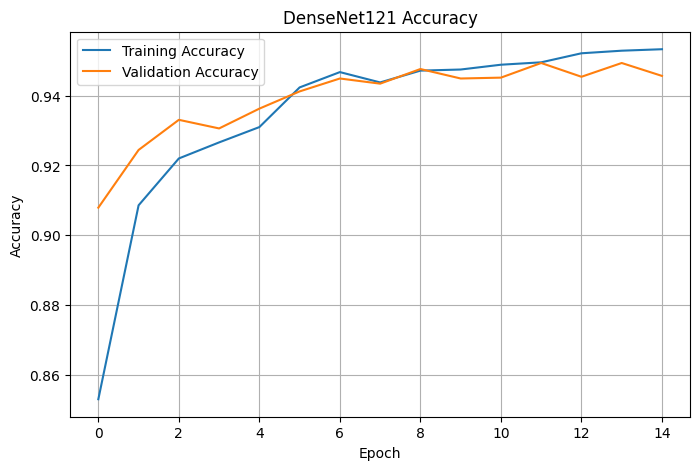

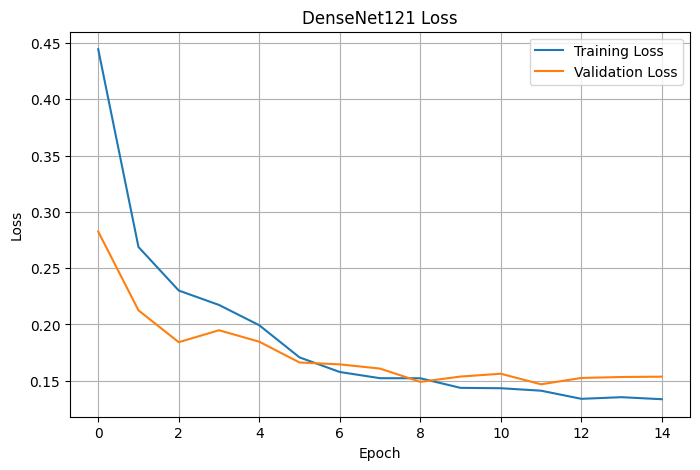

In [30]:
plot_training_history(
    training_histories,
    MODEL_NAME
)

In [32]:
MODEL_PATH = f"/kaggle/working/models/{MODEL_NAME}_best.keras"

trained_model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False,
    custom_objects={
        "preprocess_input":
            PREPROCESS_REGISTRY[MODEL_NAME]
    }
)

trained_model.summary()

Model: "DenseNet121_EuroSAT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ optical_image (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DenseNet121_preprocessing       │ (None, 64, 64, 3)      │             0 │
│ (Lambda)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_batch_norm              │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_dropout (Dropout)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_dense (Dense)           │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_dropout (Dropout)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_output (Dense)   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,306,570 (27.87 MB)

 Trainable params: 267,018 (1.02 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [78]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay,confusion_matrix,classification_report

In [79]:
pred = trained_model.predict(test_ds)

64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 196ms/step


In [80]:
print(classification_report(test_df['target'],pred.argmax(1)))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       450
           1       0.96      0.99      0.98       450
           2       0.93      0.96      0.95       450
           3       0.90      0.92      0.91       375
           4       0.97      0.97      0.97       375
           5       0.96      0.93      0.94       300
           6       0.94      0.90      0.92       375
           7       0.98      0.98      0.98       450
           8       0.95      0.90      0.92       375
           9       1.00      0.99      0.99       450

    accuracy                           0.95      4050
   macro avg       0.95      0.95      0.95      4050
weighted avg       0.95      0.95      0.95      4050



In [81]:
confusion_matrix(test_df['target'],pred.argmax(1))

array([[431,   1,   3,   2,   0,   2,   9,   0,   1,   1],
       [  0, 445,   4,   0,   0,   0,   0,   0,   0,   1],
       [  0,   4, 433,   2,   1,   3,   6,   1,   0,   0],
       [  6,   2,   3, 346,   1,   1,   5,   2,   9,   0],
       [  0,   0,   0,   5, 364,   0,   0,   6,   0,   0],
       [  4,   6,   5,   0,   0, 279,   1,   0,   5,   0],
       [ 12,   1,  13,   5,   1,   2, 339,   0,   2,   0],
       [  0,   0,   2,   1,   7,   0,   0, 439,   1,   0],
       [  5,   2,   2,  25,   3,   2,   0,   0, 336,   0],
       [  1,   1,   0,   0,   0,   2,   0,   0,   1, 445]])

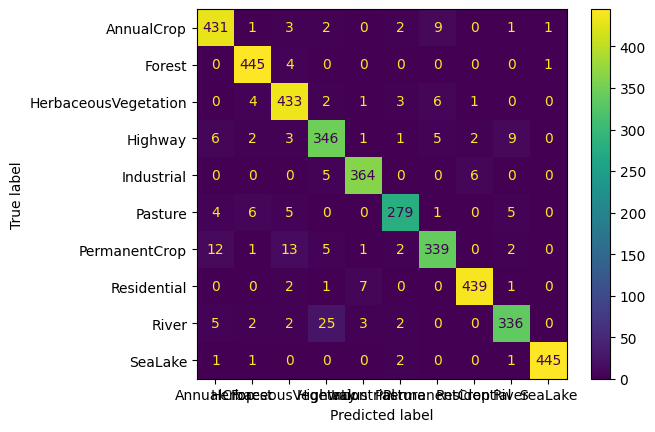

In [82]:
con_mat = confusion_matrix(
    test_df['target'],
    pred.argmax(1)
)

disp = ConfusionMatrixDisplay(
    con_mat,
    display_labels=CLASS_NAMES
)

disp.plot()
plt.show()

In [83]:
embedding_model = tf.keras.Model(
    inputs=trained_model.input,
    outputs=trained_model.get_layer("feature_dense").output,
    name="optical_embedding_model"
)

In [84]:
def normalize_embeddings(embeddings):
    return tf.math.l2_normalize(
        embeddings,
        axis=1
    )

In [85]:
retrieval_df = test_df.copy()

retrieval_df = retrieval_df.dropna(
    subset=["EuroSAT_RGB_path", "label"]
).reset_index(drop=True)

print("Gallery images:", len(retrieval_df))

Gallery images: 4050


In [86]:
gallery_embeddings = embedding_model.predict(
    test_ds,
    verbose=1
)

gallery_embeddings = normalize_embeddings(
    gallery_embeddings
).numpy()

print(
    "Gallery embedding shape:",
    gallery_embeddings.shape
)

64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 200ms/step
Gallery embedding shape: (4050, 256)


In [87]:
def extract_query_embedding(
    image_path,
    embedding_model
):
    image = load_image(
        tf.constant(str(image_path)),0
    )[0]

    image = tf.expand_dims(
        image,
        axis=0
    )

    embedding = embedding_model(
        image,
        training=False
    )

    embedding = tf.math.l2_normalize(
        embedding,
        axis=1
    )

    return embedding.numpy()

In [88]:
def retrieve_same_modal_query(
    query_index,
    dataframe,
    embeddings,
    top_k=5
):
    query_embedding = embeddings[
        query_index
    ]

    # Cosine similarity because embeddings are normalized
    similarities = np.dot(
        embeddings,
        query_embedding
    )

    # Exclude the query image itself
    similarities[query_index] = -np.inf

    ranked_indices = np.argsort(
        similarities
    )[::-1][:top_k]

    query_label = dataframe.iloc[
        query_index
    ]["label"]

    results = []

    for rank, gallery_index in enumerate(
        ranked_indices,
        start=1
    ):
        gallery_row = dataframe.iloc[
            gallery_index
        ]

        retrieved_label = gallery_row[
            "label"
        ]

        results.append({
            "rank": rank,
            "gallery_index": int(gallery_index),
            "file_id": gallery_row["file_id"],
            "label": retrieved_label,
            "image_path":
                gallery_row["EuroSAT_RGB_path"],
            "similarity":
                float(similarities[gallery_index]),
            "relevant":
                int(retrieved_label == query_label)
        })

    return pd.DataFrame(results)

In [89]:
def retrieve_similar_images(
    query_path,
    gallery_df,
    gallery_embeddings,
    embedding_model,
    top_k=5,
    exclude_query=True
):
    query_embedding = extract_query_embedding(
        query_path,
        embedding_model
    )

    # Cosine similarity
    similarities = np.dot(
        gallery_embeddings,
        query_embedding[0]
    )

    ranked_indices = np.argsort(
        similarities
    )[::-1]

    results = []

    for index in ranked_indices:

        gallery_path = gallery_df.iloc[index][
            "EuroSAT_RGB_path"
        ]

        if (
            exclude_query
            and str(gallery_path) == str(query_path)
        ):
            continue

        results.append({
            "rank": len(results) + 1,
            "index": int(index),
            "file_id": gallery_df.iloc[index][
                "file_id"
            ],
            "label": gallery_df.iloc[index][
                "label"
            ],
            "image_path": gallery_path,
            "similarity": float(
                similarities[index]
            )
        })

        if len(results) == top_k:
            break

    return pd.DataFrame(results)

In [90]:
def display_retrieval_results(
    query_path,
    query_label,
    retrieval_results
):
    total_images = len(retrieval_results) + 1

    plt.figure(
        figsize=(4 * total_images, 4)
    )

    # Query image
    query_image = Image.open(
        query_path
    ).convert("RGB")

    plt.subplot(
        1,
        total_images,
        1
    )

    plt.imshow(query_image)
    plt.title(
        f"Query\n{query_label}"
    )
    plt.axis("off")

    # Retrieved images
    for position, row in retrieval_results.iterrows():

        retrieved_image = Image.open(
            row["image_path"]
        ).convert("RGB")

        plt.subplot(
            1,
            total_images,
            position + 2
        )

        plt.imshow(retrieved_image)

        plt.title(
            f"Rank {int(row['rank'])}\n"
            f"{row['label']}\n"
            f"Similarity: {row['similarity']:.3f}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [91]:
def display_retrieval_grid(
    query_path,
    query_label,
    retrieval_results,
    columns=4
):
    total_images = len(retrieval_results) + 1
    rows = int(
        np.ceil(total_images / columns)
    )

    plt.figure(
        figsize=(4 * columns, 4 * rows)
    )

    query_image = Image.open(
        query_path
    ).convert("RGB")

    plt.subplot(
        rows,
        columns,
        1
    )

    plt.imshow(query_image)
    plt.title(
        f"Query\n{query_label}"
    )
    plt.axis("off")

    for position, row in retrieval_results.iterrows():

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        plt.subplot(
            rows,
            columns,
            position + 2
        )

        plt.imshow(image)

        plt.title(
            f"Rank {int(row['rank'])}\n"
            f"{row['label']}\n"
            f"{row['similarity']:.3f}"
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [92]:
def calculate_query_metrics(
    query_index,
    retrieval_results,
    dataframe
):
    query_label = dataframe.iloc[
        query_index
    ]["label"]

    # All relevant gallery images except the query itself
    total_relevant = (
        dataframe["label"] == query_label
    ).sum() - 1

    retrieved_relevant = retrieval_results[
        "relevant"
    ].sum()

    k = len(retrieval_results)

    precision_at_k = (
        retrieved_relevant / k
        if k > 0
        else 0.0
    )

    recall_at_k = (
        retrieved_relevant / total_relevant
        if total_relevant > 0
        else 0.0
    )

    if precision_at_k + recall_at_k > 0:
        f1_at_k = (
            2
            * precision_at_k
            * recall_at_k
            / (
                precision_at_k
                + recall_at_k
            )
        )
    else:
        f1_at_k = 0.0

    return {
        "query_index": query_index,
        "query_label": query_label,
        "k": k,
        "retrieved_relevant":
            int(retrieved_relevant),
        "total_relevant":
            int(total_relevant),
        "precision_at_k":
            precision_at_k,
        "recall_at_k":
            recall_at_k,
        "f1_at_k":
            f1_at_k
    }

In [101]:
all_metrics = []

for query_index in tqdm(range(test_df.shape[0])):

    top5_results = retrieve_same_modal_query(
        query_index=query_index,
        dataframe=test_df,
        embeddings=gallery_embeddings,
        top_k=5
    )
    
    metrics_at_5 = calculate_query_metrics(
        query_index=query_index,
        retrieval_results=top5_results,
        dataframe=test_df
    )


    all_metrics.append(metrics_at_5)

  0%|          | 0/4050 [00:00<?, ?it/s]

In [104]:
met_result = pd.DataFrame(all_metrics)
met_result

,query_index,query_label,k,retrieved_relevant,total_relevant,precision_at_k,recall_at_k,f1_at_k
0,0,PermanentCrop,5,5,374,1.0,0.013369,0.026385
1,1,SeaLake,5,3,449,0.6,0.006682,0.013216
2,2,AnnualCrop,5,5,449,1.0,0.011136,0.022026
3,3,Industrial,5,5,374,1.0,0.013369,0.026385
4,4,Highway,5,1,374,0.2,0.002674,0.005277
...,...,...,...,...,...,...,...,...
4045,4045,River,5,0,374,0.0,0.000000,0.000000
4046,4046,HerbaceousVegetation,5,5,449,1.0,0.011136,0.022026
4047,4047,Industrial,5,3,374,0.6,0.008021,0.015831
4048,4048,Forest,5,5,449,1.0,0.011136,0.022026


In [107]:
met_result['precision_at_k'].mean()m

(np.float64(0.9181728395061729), np.float64(0.022348252012217653))

In [114]:
def retrieval_metrics_at_k(
    query_index,
    dataframe,
    embeddings,
    k=5,
    label_column="label"
):
    query_embedding = embeddings[query_index]

    # Cosine similarity for normalized embeddings
    similarities = embeddings @ query_embedding

    # Exclude the query image itself
    similarities[query_index] = -np.inf

    top_k_indices = np.argsort(similarities)[::-1][:k]

    query_label = dataframe.iloc[query_index][label_column]

    retrieved_labels = dataframe.iloc[
        top_k_indices
    ][label_column].to_numpy()

    relevant_mask = retrieved_labels == query_label
    relevant_retrieved = int(relevant_mask.sum())

    total_relevant = int(
        (dataframe[label_column] == query_label).sum() - 1
    )

    precision = relevant_retrieved / k

    recall = (
        relevant_retrieved / total_relevant
        if total_relevant > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall / (precision + recall)
        if precision + recall > 0
        else 0.0
    )

    return {
        "query_index": query_index,
        "query_label": query_label,
        f"precision_at_{k}": precision,
        f"recall_at_{k}": recall,
        f"f1_at_{k}": f1,
        "top_k_indices": top_k_indices
    }

In [115]:
def evaluate_image_retrieval(
    dataframe,
    embeddings,
    k_values=(5, 10),
    label_column="label"
):
    rows = []
    retrieval_times = []

    labels = dataframe[label_column].to_numpy()

    for query_index in range(len(dataframe)):

        start_time = time.perf_counter()

        query_embedding = embeddings[query_index]

        similarities = embeddings @ query_embedding
        similarities[query_index] = -np.inf

        max_k = max(k_values)
        ranked_indices = np.argsort(
            similarities
        )[::-1][:max_k]

        retrieval_times.append(
            time.perf_counter() - start_time
        )

        query_label = labels[query_index]

        total_relevant = int(
            np.sum(labels == query_label) - 1
        )

        row = {
            "query_index": query_index,
            "query_label": query_label
        }

        for k in k_values:

            top_k_indices = ranked_indices[:k]

            relevant_retrieved = int(
                np.sum(
                    labels[top_k_indices] == query_label
                )
            )

            precision = relevant_retrieved / k

            recall = (
                relevant_retrieved / total_relevant
                if total_relevant > 0
                else 0.0
            )

            f1 = (
                2 * precision * recall
                / (precision + recall)
                if precision + recall > 0
                else 0.0
            )

            row[f"relevant_at_{k}"] = relevant_retrieved
            row[f"precision_at_{k}"] = precision
            row[f"recall_at_{k}"] = recall
            row[f"f1_at_{k}"] = f1

        rows.append(row)

    query_metrics_df = pd.DataFrame(rows)

    summary = {
        "number_of_queries": len(dataframe),

        "precision_at_5":
            query_metrics_df["precision_at_5"].mean(),

        "recall_at_5":
            query_metrics_df["recall_at_5"].mean(),

        "f1_at_5":
            query_metrics_df["f1_at_5"].mean(),

        "precision_at_10":
            query_metrics_df["precision_at_10"].mean(),

        "recall_at_10":
            query_metrics_df["recall_at_10"].mean(),

        "f1_at_10":
            query_metrics_df["f1_at_10"].mean(),

        "average_retrieval_time_ms":
            np.mean(retrieval_times) * 1000
    }

    return query_metrics_df, pd.DataFrame([summary])

In [116]:
query_metrics_df, retrieval_summary_df = (
    evaluate_image_retrieval(
        dataframe=test_df,
        embeddings=gallery_embeddings,
        k_values=(5, 10),
        label_column="label"
    )
)

display(retrieval_summary_df)

,number_of_queries,precision_at_5,recall_at_5,f1_at_5,precision_at_10,recall_at_10,f1_at_10,average_retrieval_time_ms
0,4050,0.918173,0.011314,0.022348,0.91237,0.02248,0.043861,0.178137


341 /kaggle/input/datasets/glitchr/eurodata/EuroSAT_RGB/EuroSAT_RGB/Residential/Residential_1248.jpg Residential


,rank,index,file_id,label,image_path,similarity
0,1,2830,2273,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.813038
1,2,3509,567,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.800615
2,3,2849,2472,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.777482
3,4,3597,1383,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.768515
4,5,1436,2622,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.767776
5,6,2562,392,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.758023
6,7,4012,1091,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.757459
7,8,323,152,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.757014
8,9,788,1643,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.756965
9,10,3282,893,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.753894


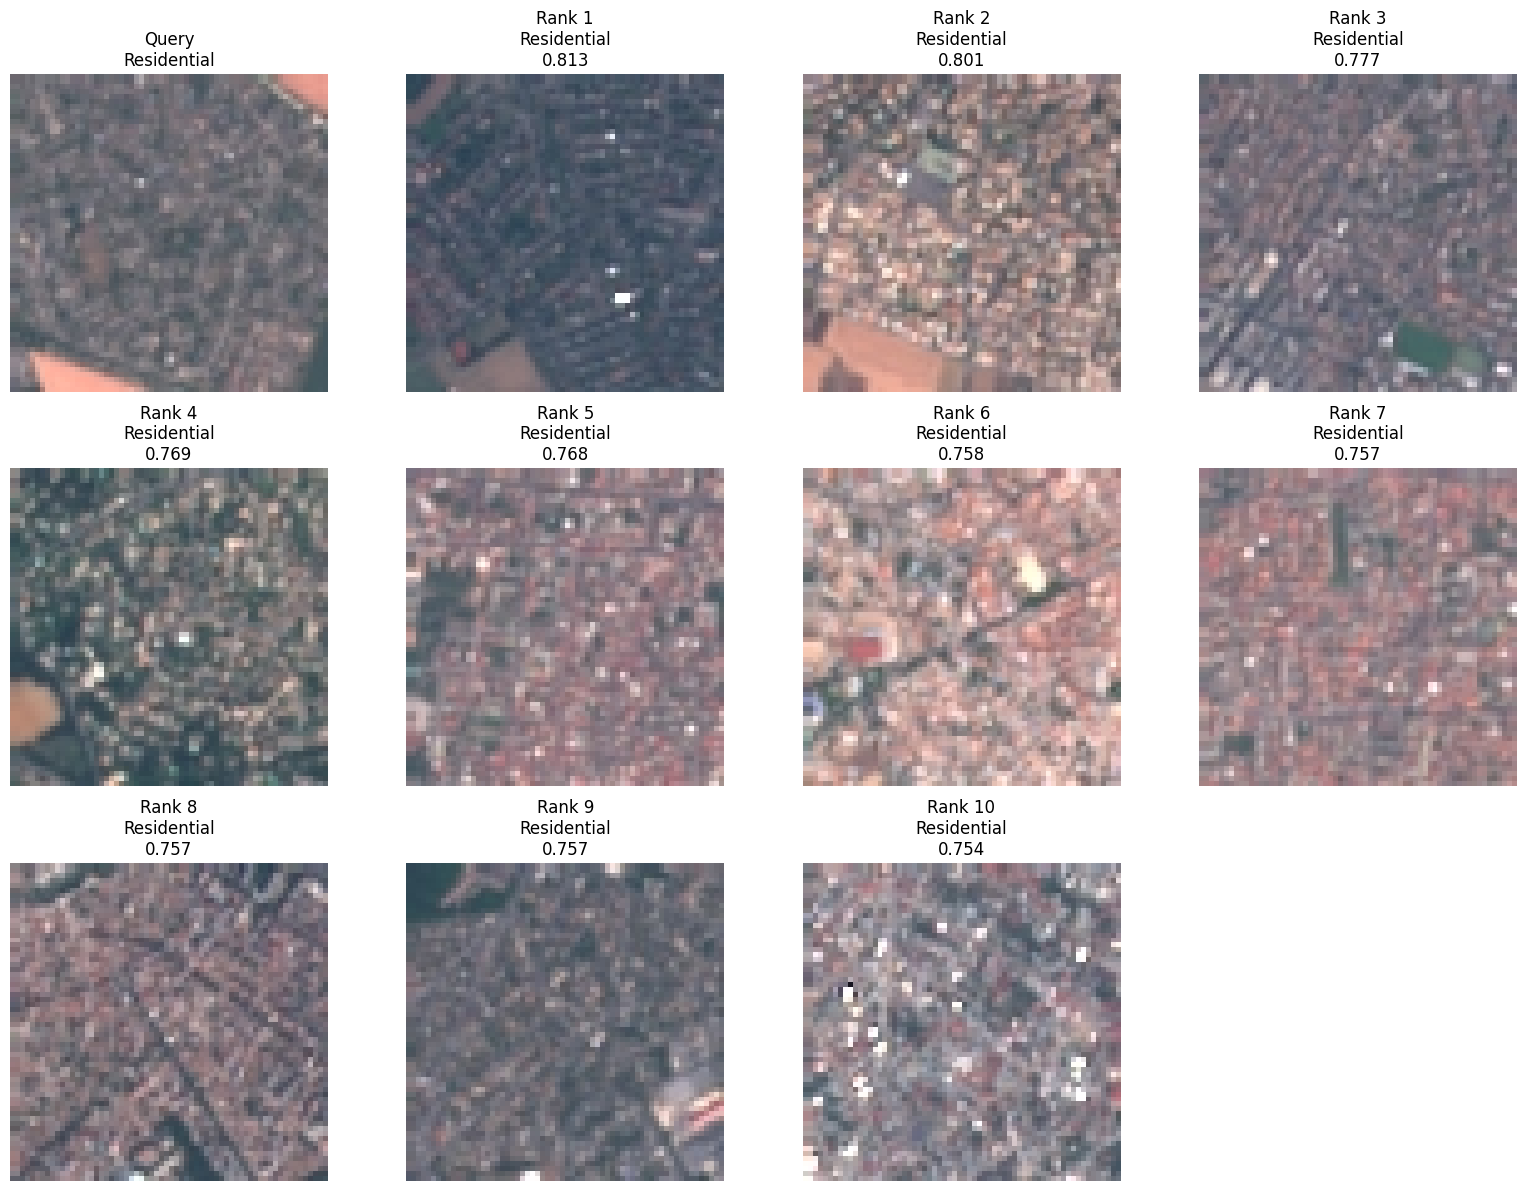

In [93]:
query_index = np.random.randint(test_df.shape[0])

query_path = retrieval_df.iloc[
    query_index
]["EuroSAT_RGB_path"]

query_label = retrieval_df.iloc[
    query_index
]["label"]
print(query_index,query_path,query_label)
results = retrieve_similar_images(
    query_path=query_path,
    gallery_df=retrieval_df,
    gallery_embeddings=gallery_embeddings,
    embedding_model=embedding_model,
    top_k=10
)
display(results)
display_retrieval_grid(
    query_path=query_path,
    query_label=query_label,
    retrieval_results=results,
    columns=4
)

In [97]:
top5_results = retrieve_same_modal_query(
    query_index=query_index,
    dataframe=test_df,
    embeddings=gallery_embeddings,
    top_k=5
)

display(top5_results)
metrics_at_5 = calculate_query_metrics(
    query_index=query_index,
    retrieval_results=top5_results,
    dataframe=test_df
)

print("Same-modal RGB → RGB")
print("Query label:", metrics_at_5["query_label"])
print("Precision@5:", round(
    metrics_at_5["precision_at_k"], 4
))
print("Recall@5:", round(
    metrics_at_5["recall_at_k"], 4
))
print("F1-score@5:", round(
    metrics_at_5["f1_at_k"], 4
))

,rank,gallery_index,file_id,label,image_path,similarity,relevant
0,1,3509,567,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.803436,1
1,2,2849,2472,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.798853,1
2,3,3945,2378,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.785704,1
3,4,2562,392,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.785531,1
4,5,2830,2273,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.784575,1


Same-modal RGB → RGB
Query label: Residential
Precision@5: 1.0
Recall@5: 0.0111
F1-score@5: 0.022


In [98]:
top5_results = retrieve_same_modal_query(
    query_index=query_index,
    dataframe=test_df,
    embeddings=gallery_embeddings,
    top_k=10
)

display(top5_results)
metrics_at_5 = calculate_query_metrics(
    query_index=query_index,
    retrieval_results=top5_results,
    dataframe=test_df
)

print("Same-modal RGB → RGB")
print("Query label:", metrics_at_5["query_label"])
print("Precision@5:", round(
    metrics_at_5["precision_at_k"], 4
))
print("Recall@5:", round(
    metrics_at_5["recall_at_k"], 4
))
print("F1-score@5:", round(
    metrics_at_5["f1_at_k"], 4
))

,rank,gallery_index,file_id,label,image_path,similarity,relevant
0,1,3509,567,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.803436,1
1,2,2849,2472,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.798853,1
2,3,3945,2378,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.785704,1
3,4,2562,392,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.785531,1
4,5,2830,2273,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.784575,1
5,6,1436,2622,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.781531,1
6,7,3282,893,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.780570,1
7,8,3597,1383,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.775987,1
8,9,3145,2463,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.775829,1
9,10,777,829,Residential,/kaggle/input/datasets/glitchr/eurodata/EuroSA...,0.774437,1


Same-modal RGB → RGB
Query label: Residential
Precision@5: 1.0
Recall@5: 0.0223
F1-score@5: 0.0436


In [44]:
np.save(
    "/kaggle/working/optical_gallery_embeddings.npy",
    gallery_embeddings
)

retrieval_df.to_csv(
    "/kaggle/working/optical_gallery_metadata.csv",
    index=False
)